# Unità 5 — Rumore e decoerenza: primo modello bit-flip

In questo notebook introduciamo un primo modello di rumore sul canale quantistico. Il modello è semplificato: con probabilità `p` il canale applica un bit-flip, cioè un gate `X`, al qubit trasmesso da Alice a Bob.

## Setup e import

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()

if (current_path / "src" / "bb84_noise.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "bb84_noise.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Non trovo la cartella src del progetto.")

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Project root:", project_root)

Project root: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bb84_noise import (
    run_bb84_round_with_bit_flip_noise,
    run_bb84_protocol_with_bit_flip_noise,
    run_bb84_round_with_amplitude_damping,
    run_bb84_protocol_with_amplitude_damping,
    compute_lambda_from_attenuation,
    compute_time_from_distance,
    compute_c1_amplitude,
    compute_jc_damping_probability,
    compute_jc_damping_probability_from_distance,
    run_bb84_protocol_with_jc_amplitude_damping,
)
from bb84 import sift_keys, compute_qber
from e91 import sift_keys as sift_keys_e91
from e91 import compute_qber as compute_qber_e91
from e91_noise import (
    run_e91_protocol_with_bit_flip_noise,
    run_chsh_experiment_with_bit_flip_noise,
    run_e91_protocol_with_amplitude_damping,
    run_chsh_experiment_with_amplitude_damping,
    run_e91_protocol_with_jc_amplitude_damping,
    run_chsh_experiment_with_jc_amplitude_damping,
    compute_e91_jc_channel_parameters,
)
from metrics import (
    summarize_qkd_results,
    QBER_THRESHOLD_BB84,
    CHSH_CLASSICAL_LIMIT,
    CHSH_TSIRELSON_BOUND,
)

## Interpretazione del rumore bit-flip

Il bit-flip è un modello semplice di errore. Nel circuito viene rappresentato con il gate `X`: con probabilità `noise_probability` il gate viene applicato al qubit, mentre con probabilità `1 - noise_probability` il qubit non viene alterato. La variabile `noise_applied` indica se in quello specifico round il bit-flip è stato applicato.

Il bit-flip non produce lo stesso effetto sulle basi `Z` e `X`. In base `Z` inverte il bit, mentre in base `X` può non modificare il risultato della misura, perché `X|+⟩ = |+⟩` e `X|-⟩ = -|-⟩`, dove il segno globale non cambia le probabilità di misura.

## Singolo round con rumore

In [3]:
round_z = run_bb84_round_with_bit_flip_noise(
    alice_bit=1,
    alice_basis="Z",
    bob_basis="Z",
    noise_probability=1.0,
    seed=10,
)

print("Round in base Z con bit-flip sempre applicato:")
print(round_z)

Round in base Z con bit-flip sempre applicato:
{'alice_bit': 1, 'alice_basis': 'Z', 'bob_basis': 'Z', 'bob_bit': 0, 'noise_applied': True}


Con probabilità di rumore pari a `1.0`, il bit-flip viene sempre applicato. In base `Z` ci si aspetta un'inversione del bit misurato da Bob.

In [4]:
round_x = run_bb84_round_with_bit_flip_noise(
    alice_bit=0,
    alice_basis="X",
    bob_basis="X",
    noise_probability=1.0,
    seed=10,
)

print("Round in base X con bit-flip sempre applicato:")
print(round_x)

Round in base X con bit-flip sempre applicato:
{'alice_bit': 0, 'alice_basis': 'X', 'bob_basis': 'X', 'bob_bit': 0, 'noise_applied': True}


In base `X`, il gate `X` non produce necessariamente un errore osservabile nella misura. Per questo il rumore bit-flip ha un effetto diverso a seconda della base usata.

## Protocollo multi-round con rumore fissato

In [4]:
n_rounds = 500
noise_probability = 0.2
qber_threshold = 0.11
seed = 123

results_noise = run_bb84_protocol_with_bit_flip_noise(
    n_rounds=n_rounds,
    noise_probability=noise_probability,
    seed=seed,
)

alice_key_noise, bob_key_noise = sift_keys(results_noise)
qber_noise = compute_qber(alice_key_noise, bob_key_noise)

summary_noise = summarize_qkd_results(
    protocol_name="BB84 bit-flip noise",
    results=results_noise,
    alice_key=alice_key_noise,
    bob_key=bob_key_noise,
    qber=qber_noise,
    qber_threshold=qber_threshold,
)

print("Riassunto BB84 con rumore bit-flip:")
print(summary_noise)

Riassunto BB84 con rumore bit-flip:
{'protocol': 'BB84 bit-flip noise', 'n_rounds': 500, 'kept_rounds': 266, 'discarded_rounds': 234, 'sifted_key_length': 266, 'sifted_key_rate': 0.532, 'qber': 0.10150375939849623, 'qber_threshold': 0.11, 'accepted': True}


## Tabella dei primi round

In [6]:
df_noise = pd.DataFrame(results_noise)
df_noise.head(10)

,round,alice_bit,alice_basis,bob_basis,bob_bit,keep,noise_applied
0,1,0,X,Z,1,False,False
1,2,1,X,X,1,True,False
2,3,1,X,Z,0,False,False
3,4,0,X,Z,1,False,True
4,5,1,X,Z,1,False,False
5,6,0,X,Z,0,False,False
6,7,0,Z,X,0,False,False
7,8,0,X,Z,0,False,False
8,9,0,X,X,0,True,False
9,10,0,X,Z,0,False,True


La colonna `noise_applied` indica se il bit-flip è stato applicato nel round specifico. La colonna `keep` indica invece se Alice e Bob hanno usato la stessa base e quindi se il round entra nella chiave sifted.

## QBER al variare della probabilità di rumore

Ora ripetiamo la simulazione per diversi valori di `noise_probability`. In questo modo osserviamo come cambiano QBER, lunghezza della chiave sifted e decisione di accettazione della chiave.

In [5]:
noise_probabilities = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]
n_rounds_sweep = 1000
qber_threshold_sweep = 0.11
sweep_results = []

for i in range(len(noise_probabilities)):
    probability = noise_probabilities[i]
    results = run_bb84_protocol_with_bit_flip_noise(
        n_rounds=n_rounds_sweep,
        noise_probability=probability,
        seed=200 + i,
    )
    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="BB84 bit-flip noise",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_sweep,
    )
    summary["noise_probability"] = probability
    sweep_results.append(summary)

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,noise_probability
0,BB84 bit-flip noise,1000,479,521,479,0.479,0.000000,0.11,True,0.00
1,BB84 bit-flip noise,1000,511,489,511,0.511,0.031311,0.11,True,0.05
2,BB84 bit-flip noise,1000,500,500,500,0.500,0.050000,0.11,True,0.10
3,BB84 bit-flip noise,1000,515,485,515,0.515,0.075728,0.11,True,0.20
4,BB84 bit-flip noise,1000,497,503,497,0.497,0.130785,0.11,False,0.30
5,BB84 bit-flip noise,1000,448,552,448,0.448,0.176339,0.11,False,0.40


## Grafico QBER vs rumore

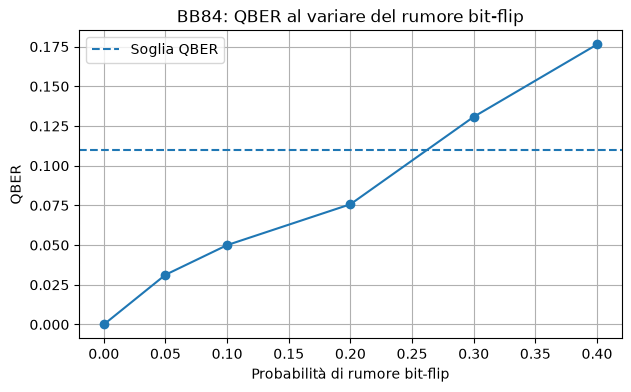

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("QBER")
plt.title("BB84: QBER al variare del rumore bit-flip")
plt.grid(True)
plt.legend()
plt.show()

## Grafico sifted key rate vs rumore

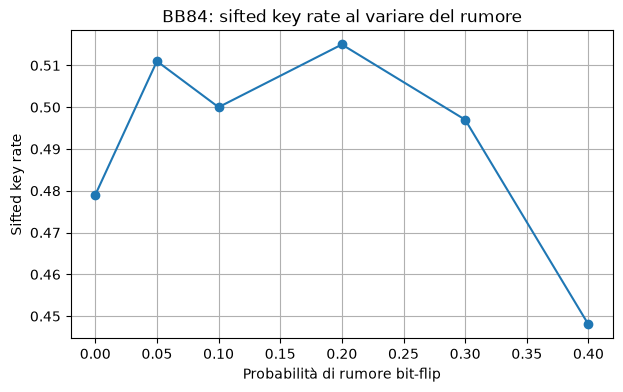

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("Sifted key rate")
plt.title("BB84: sifted key rate al variare del rumore")
plt.grid(True)
plt.show()

## Commento interpretativo

Aumentando la probabilità di rumore, il QBER tende ad aumentare. Il `sifted_key_rate` dipende soprattutto dal confronto delle basi scelte da Alice e Bob, quindi non cambia necessariamente molto con questo modello. La soglia QBER permette di decidere quando una chiave è accettata o rifiutata. Il modello bit-flip è didattico e non descrive tutti i possibili rumori fisici; nel blocco successivo si potrà introdurre amplitude damping, più vicino a un modello di dissipazione e decoerenza.

## BB84 con amplitude damping

L'amplitude damping è un modello di rumore più fisico del bit-flip, perché rappresenta una perdita di eccitazione dal livello `|1⟩` verso il livello `|0⟩`. Nel circuito il canale rumoroso è rappresentato tramite un'istruzione identity `id`, alla quale Qiskit Aer associa il noise model. Questo modello è asimmetrico: `|0⟩` è stabile, mentre `|1⟩` può decadere verso `|0⟩`. Per questo è utile come primo modello di dissipazione e decoerenza.

In [8]:
round_damping_z = run_bb84_round_with_amplitude_damping(
    alice_bit=1,
    alice_basis="Z",
    bob_basis="Z",
    damping_probability=1.0,
    seed=10,
)

print(round_damping_z)

{'alice_bit': 1, 'alice_basis': 'Z', 'bob_basis': 'Z', 'bob_bit': 0, 'damping_probability': 1.0}


Con `damping_probability = 1.0` e base `Z`, lo stato `|1⟩` tende a decadere verso `|0⟩`. Quindi Bob può ottenere `0` anche se Alice ha inviato `1`.

In [9]:
round_damping_zero = run_bb84_round_with_amplitude_damping(
    alice_bit=0,
    alice_basis="Z",
    bob_basis="Z",
    damping_probability=1.0,
    seed=10,
)

print(round_damping_zero)

{'alice_bit': 0, 'alice_basis': 'Z', 'bob_basis': 'Z', 'bob_bit': 0, 'damping_probability': 1.0}


Se Alice invia `|0⟩`, l'amplitude damping non produce decadimento verso un livello più basso. In questo senso lo stato `|0⟩` è stabile rispetto a questo modello.

## Protocollo multi-round con amplitude damping fissato

In [10]:
n_rounds_damping = 500
damping_probability = 0.2
qber_threshold_damping = 0.11
seed_damping = 321

results_damping = run_bb84_protocol_with_amplitude_damping(
    n_rounds=n_rounds_damping,
    damping_probability=damping_probability,
    seed=seed_damping,
)

alice_key_damping, bob_key_damping = sift_keys(results_damping)
qber_damping = compute_qber(alice_key_damping, bob_key_damping)

summary_damping = summarize_qkd_results(
    protocol_name="BB84 amplitude damping",
    results=results_damping,
    alice_key=alice_key_damping,
    bob_key=bob_key_damping,
    qber=qber_damping,
    qber_threshold=qber_threshold_damping,
)

print(summary_damping)

{'protocol': 'BB84 amplitude damping', 'n_rounds': 500, 'kept_rounds': 243, 'discarded_rounds': 257, 'sifted_key_length': 243, 'sifted_key_rate': 0.486, 'qber': 0.06584362139917696, 'qber_threshold': 0.11, 'accepted': True}


## Tabella dei primi round amplitude damping

In [11]:
df_damping = pd.DataFrame(results_damping)
df_damping.head(10)

,round,alice_bit,alice_basis,bob_basis,bob_bit,keep,damping_probability
0,1,0,Z,X,1,False,0.2
1,2,1,Z,Z,0,True,0.2
2,3,0,Z,X,0,False,0.2
3,4,1,Z,X,1,False,0.2
4,5,1,Z,Z,1,True,0.2
5,6,0,Z,X,1,False,0.2
6,7,0,Z,X,0,False,0.2
7,8,1,Z,X,1,False,0.2
8,9,0,X,Z,1,False,0.2
9,10,1,X,Z,0,False,0.2


La colonna `damping_probability` non indica se il decadimento è avvenuto in quel singolo round. Indica invece il parametro del noise model usato dal simulatore per quel round.

## QBER al variare dell'amplitude damping

Ripetiamo la simulazione per diversi valori di `damping_probability`. In questo modo possiamo osservare come il decadimento influenzi il QBER e le metriche della chiave sifted.

In [12]:
damping_probabilities = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]
n_rounds_damping_sweep = 1000
qber_threshold_damping_sweep = 0.11
damping_sweep_results = []

for i in range(len(damping_probabilities)):
    probability = damping_probabilities[i]

    results = run_bb84_protocol_with_amplitude_damping(
        n_rounds=n_rounds_damping_sweep,
        damping_probability=probability,
        seed=500 + i,
    )

    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)

    summary = summarize_qkd_results(
        protocol_name="BB84 amplitude damping",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_damping_sweep,
    )

    summary["damping_probability"] = probability
    damping_sweep_results.append(summary)

damping_sweep_df = pd.DataFrame(damping_sweep_results)
damping_sweep_df

,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,damping_probability
0,BB84 amplitude damping,1000,490,510,490,0.490,0.000000,0.11,True,0.00
1,BB84 amplitude damping,1000,513,487,513,0.513,0.017544,0.11,True,0.05
2,BB84 amplitude damping,1000,521,479,521,0.521,0.036468,0.11,True,0.10
3,BB84 amplitude damping,1000,510,490,510,0.510,0.062745,0.11,True,0.20
4,BB84 amplitude damping,1000,536,464,536,0.536,0.093284,0.11,True,0.30
5,BB84 amplitude damping,1000,497,503,497,0.497,0.160966,0.11,False,0.40


## Grafico QBER vs amplitude damping

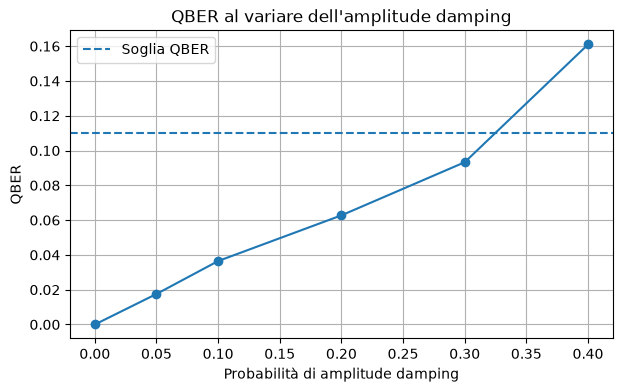

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_damping_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("QBER")
plt.title("QBER al variare dell'amplitude damping")
plt.grid(True)
plt.legend()
plt.show()

## Grafico sifted key rate vs amplitude damping

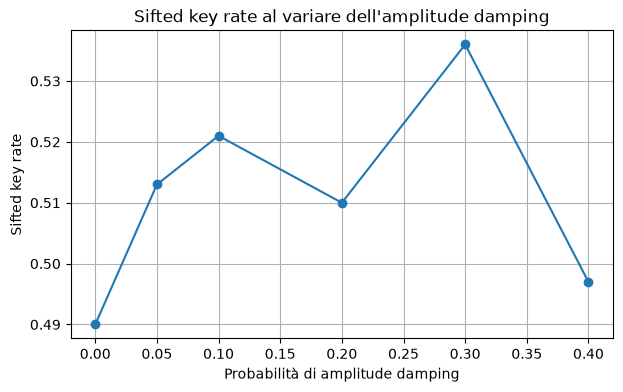

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("Sifted key rate")
plt.title("Sifted key rate al variare dell'amplitude damping")
plt.grid(True)
plt.show()

## Confronto tra bit-flip noise e amplitude damping

In [15]:
comparison_noise_rows = []

for i in range(len(sweep_df)):
    row = {
        "noise_model": "bit-flip",
        "probability": sweep_df.loc[i, "noise_probability"],
        "qber": sweep_df.loc[i, "qber"],
        "sifted_key_rate": sweep_df.loc[i, "sifted_key_rate"],
        "accepted": sweep_df.loc[i, "accepted"],
    }
    comparison_noise_rows.append(row)

for i in range(len(damping_sweep_df)):
    row = {
        "noise_model": "amplitude damping",
        "probability": damping_sweep_df.loc[i, "damping_probability"],
        "qber": damping_sweep_df.loc[i, "qber"],
        "sifted_key_rate": damping_sweep_df.loc[i, "sifted_key_rate"],
        "accepted": damping_sweep_df.loc[i, "accepted"],
    }
    comparison_noise_rows.append(row)

noise_comparison_df = pd.DataFrame(comparison_noise_rows)
noise_comparison_df

,noise_model,probability,qber,sifted_key_rate,accepted
0,bit-flip,0.00,0.000000,0.479,True
1,bit-flip,0.05,0.031311,0.511,True
2,bit-flip,0.10,0.050000,0.500,True
3,bit-flip,0.20,0.075728,0.515,True
4,bit-flip,0.30,0.130785,0.497,False
5,bit-flip,0.40,0.176339,0.448,False
6,amplitude damping,0.00,0.000000,0.490,True
7,amplitude damping,0.05,0.017544,0.513,True
8,amplitude damping,0.10,0.036468,0.521,True
9,amplitude damping,0.20,0.062745,0.510,True


## Grafico confronto QBER

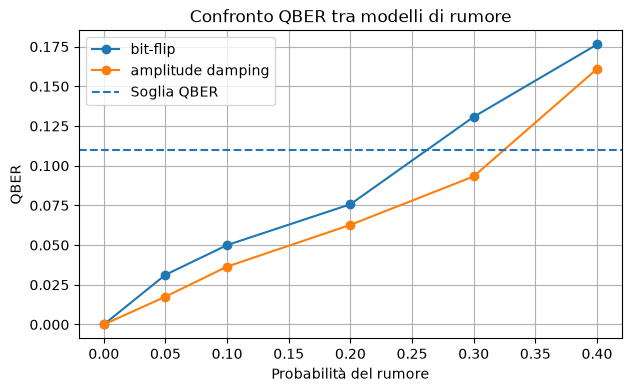

In [16]:
bit_flip_df = noise_comparison_df[noise_comparison_df["noise_model"] == "bit-flip"]
amplitude_df = noise_comparison_df[noise_comparison_df["noise_model"] == "amplitude damping"]

plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["qber"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["qber"],
    marker="o",
    label="amplitude damping",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("QBER")
plt.title("Confronto QBER tra modelli di rumore")
plt.grid(True)
plt.legend()
plt.show()

## Grafico confronto sifted key rate

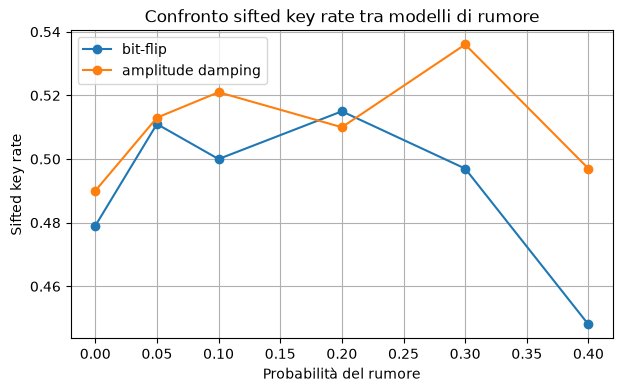

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["sifted_key_rate"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["sifted_key_rate"],
    marker="o",
    label="amplitude damping",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("Sifted key rate")
plt.title("Confronto sifted key rate tra modelli di rumore")
plt.grid(True)
plt.legend()
plt.show()

## Commento interpretativo finale

Bit-flip e amplitude damping sono due modelli diversi. Il bit-flip applica una inversione discreta tramite il gate `X`, mentre l'amplitude damping descrive una perdita di eccitazione da `|1⟩` verso `|0⟩`. Entrambi possono aumentare il QBER. Il `sifted_key_rate` resta invece legato soprattutto alla probabilità che Alice e Bob scelgano la stessa base. L'amplitude damping è più utile per collegare il progetto al tema della dissipazione e della decoerenza. Una modellazione ancora più realistica potrebbe collegare `damping_probability` a distanza, attenuazione o tempo di propagazione.

## Modello Jaynes-Cummings semplificato e distanza del canale

Nelle sezioni precedenti abbiamo trattato `damping_probability` come un parametro scelto direttamente. In questa sezione, invece, la probabilità di damping viene calcolata a partire dalla distanza del canale usando una versione semplificata del modello Jaynes-Cummings discusso nell'articolo fornito dal docente.

La catena concettuale è: distanza `d` -> tempo di propagazione `t = d / v` -> parametro `lambda` dalla attenuazione della fibra -> ampiezza `C1(t)` -> `damping_probability = 1 - |C1(t)|²` -> simulazione BB84 -> QBER.

Questa è una versione didattica e semplificata del modello dell'articolo, non una riproduzione completa dei dati sperimentali.

## Parametri fisici semplificati

In [18]:
fiber_speed_km_s = 203390
attenuation_db_per_km = 0.21
coupling_ratio = 0.1

lambda_parameter = compute_lambda_from_attenuation(
    attenuation_db_per_km=attenuation_db_per_km,
    fiber_speed_km_s=fiber_speed_km_s,
)

print("Velocità nella fibra (km/s):", fiber_speed_km_s)
print("Attenuazione fibra (dB/km):", attenuation_db_per_km)
print("Coupling ratio R:", coupling_ratio)
print("Parametro lambda:", lambda_parameter)

Velocità nella fibra (km/s): 203390
Attenuazione fibra (dB/km): 0.21
Coupling ratio R: 0.1
Parametro lambda: 9834.778423345238


`fiber_speed_km_s` è la velocità di propagazione nella fibra. `attenuation_db_per_km` rappresenta l'attenuazione della fibra. `coupling_ratio` è il parametro `R = Gamma0 / lambda`. Il parametro `lambda_parameter` controlla la scala temporale della dissipazione.

## Damping probability al variare della distanza per R = 0.1

In [19]:
distances_km = [0, 10, 20, 30, 40, 50, 75, 100]
jc_damping_rows = []

for i in range(len(distances_km)):
    distance = distances_km[i]

    time_s = compute_time_from_distance(
        distance_km=distance,
        fiber_speed_km_s=fiber_speed_km_s,
    )

    damping_probability = compute_jc_damping_probability_from_distance(
        distance_km=distance,
        attenuation_db_per_km=attenuation_db_per_km,
        coupling_ratio=coupling_ratio,
        fiber_speed_km_s=fiber_speed_km_s,
    )

    row = {
        "distance_km": distance,
        "time_s": time_s,
        "attenuation_db_per_km": attenuation_db_per_km,
        "coupling_ratio": coupling_ratio,
        "damping_probability": damping_probability,
    }

    jc_damping_rows.append(row)

jc_damping_df = pd.DataFrame(jc_damping_rows)
jc_damping_df

,distance_km,time_s,attenuation_db_per_km,coupling_ratio,damping_probability
0,0,0.000000,0.21,0.1,0.000000
1,10,0.000049,0.21,0.1,0.009979
2,20,0.000098,0.21,0.1,0.034302
3,30,0.000147,0.21,0.1,0.066814
4,40,0.000197,0.21,0.1,0.103603
5,50,0.000246,0.21,0.1,0.142236
6,75,0.000369,0.21,0.1,0.238556
7,100,0.000492,0.21,0.1,0.327856


Nel regime considerato la `damping_probability` cresce con la distanza. Questo valore, però, non rappresenta da solo tutte le sorgenti di errore di un apparato reale.

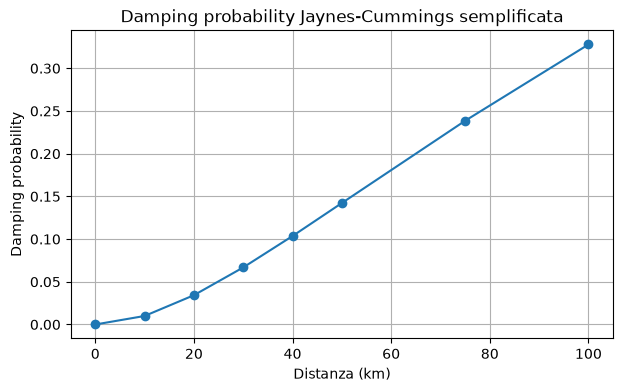

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(
    jc_damping_df["distance_km"],
    jc_damping_df["damping_probability"],
    marker="o",
)
plt.xlabel("Distanza (km)")
plt.ylabel("Damping probability")
plt.title("Damping probability Jaynes-Cummings semplificata")
plt.grid()
plt.show()

## QBER vs distanza per R = 0.1

Ora usiamo la `damping_probability` calcolata dal modello per eseguire BB84 e calcolare il QBER sulla chiave sifted.

In [21]:
n_rounds_jc = 1000
qber_threshold_jc = 0.11
jc_distance_results = []

for i in range(len(distances_km)):
    distance = distances_km[i]

    results = run_bb84_protocol_with_jc_amplitude_damping(
        n_rounds=n_rounds_jc,
        distance_km=distance,
        attenuation_db_per_km=attenuation_db_per_km,
        coupling_ratio=coupling_ratio,
        fiber_speed_km_s=fiber_speed_km_s,
        seed=900 + i,
    )

    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)

    summary = summarize_qkd_results(
        protocol_name="BB84 JC amplitude damping",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_jc,
    )

    damping_probability = compute_jc_damping_probability_from_distance(
        distance_km=distance,
        attenuation_db_per_km=attenuation_db_per_km,
        coupling_ratio=coupling_ratio,
        fiber_speed_km_s=fiber_speed_km_s,
    )

    summary["distance_km"] = distance
    summary["attenuation_db_per_km"] = attenuation_db_per_km
    summary["coupling_ratio"] = coupling_ratio
    summary["damping_probability"] = damping_probability

    jc_distance_results.append(summary)

jc_distance_df = pd.DataFrame(jc_distance_results)
jc_distance_df

,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,distance_km,attenuation_db_per_km,coupling_ratio,damping_probability
0,BB84 JC amplitude damping,1000,492,508,492,0.492,0.000000,0.11,True,0,0.21,0.1,0.000000
1,BB84 JC amplitude damping,1000,494,506,494,0.494,0.002024,0.11,True,10,0.21,0.1,0.009979
2,BB84 JC amplitude damping,1000,503,497,503,0.503,0.011928,0.11,True,20,0.21,0.1,0.034302
3,BB84 JC amplitude damping,1000,486,514,486,0.486,0.012346,0.11,True,30,0.21,0.1,0.066814
4,BB84 JC amplitude damping,1000,496,504,496,0.496,0.042339,0.11,True,40,0.21,0.1,0.103603
5,BB84 JC amplitude damping,1000,495,505,495,0.495,0.050505,0.11,True,50,0.21,0.1,0.142236
6,BB84 JC amplitude damping,1000,464,536,464,0.464,0.077586,0.11,True,75,0.21,0.1,0.238556
7,BB84 JC amplitude damping,1000,505,495,505,0.505,0.142574,0.11,False,100,0.21,0.1,0.327856


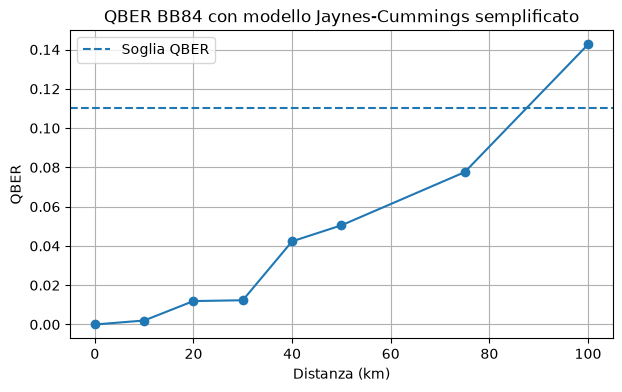

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(
    jc_distance_df["distance_km"],
    jc_distance_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_jc,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Distanza (km)")
plt.ylabel("QBER")
plt.title("QBER BB84 con modello Jaynes-Cummings semplificato")
plt.grid()
plt.legend()
plt.show()

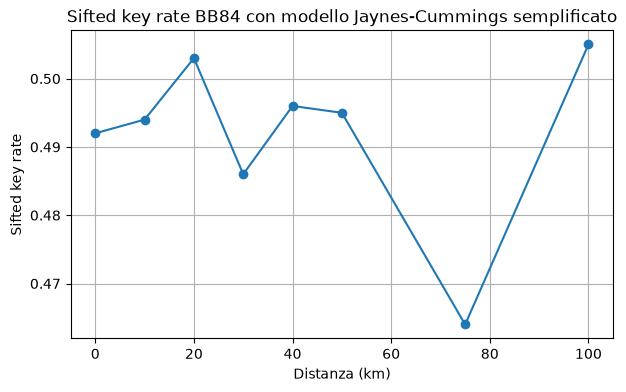

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(
    jc_distance_df["distance_km"],
    jc_distance_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Distanza (km)")
plt.ylabel("Sifted key rate")
plt.title("Sifted key rate BB84 con modello Jaynes-Cummings semplificato")
plt.grid()
plt.show()

Il `sifted_key_rate` resta legato soprattutto alla scelta delle basi, mentre la qualità della chiave è misurata dal QBER.

## Effetto del parametro R

Il parametro `R` controlla la forza relativa dell'accoppiamento sistema-ambiente. Valori piccoli producono una dissipazione più moderata; valori più grandi portano a una dinamica più intensa e possono avvicinare il modello al regime non markoviano. Nel notebook consideriamo tre valori: `R = 0.1`, `R = 0.3` e `R = 0.49`. Il valore `R = 0.49` è vicino al valore critico `0.5` nella formula semplificata, quindi va interpretato con cautela.

In [24]:
coupling_ratios = [0.1, 0.3, 0.49]
jc_multi_r_results = []

for r_index in range(len(coupling_ratios)):
    current_r = coupling_ratios[r_index]

    for d_index in range(len(distances_km)):
        distance = distances_km[d_index]

        results = run_bb84_protocol_with_jc_amplitude_damping(
            n_rounds=n_rounds_jc,
            distance_km=distance,
            attenuation_db_per_km=attenuation_db_per_km,
            coupling_ratio=current_r,
            fiber_speed_km_s=fiber_speed_km_s,
            seed=1200 + r_index * 100 + d_index,
        )

        alice_key, bob_key = sift_keys(results)
        qber = compute_qber(alice_key, bob_key)

        summary = summarize_qkd_results(
            protocol_name="BB84 JC amplitude damping",
            results=results,
            alice_key=alice_key,
            bob_key=bob_key,
            qber=qber,
            qber_threshold=qber_threshold_jc,
        )

        damping_probability = compute_jc_damping_probability_from_distance(
            distance_km=distance,
            attenuation_db_per_km=attenuation_db_per_km,
            coupling_ratio=current_r,
            fiber_speed_km_s=fiber_speed_km_s,
        )

        summary["distance_km"] = distance
        summary["attenuation_db_per_km"] = attenuation_db_per_km
        summary["coupling_ratio"] = current_r
        summary["damping_probability"] = damping_probability

        jc_multi_r_results.append(summary)

jc_multi_r_df = pd.DataFrame(jc_multi_r_results)
jc_multi_r_df

,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,distance_km,attenuation_db_per_km,coupling_ratio,damping_probability
0,BB84 JC amplitude damping,1000,479,521,479,0.479,0.000000,0.11,True,0,0.21,0.10,0.000000
1,BB84 JC amplitude damping,1000,497,503,497,0.497,0.002012,0.11,True,10,0.21,0.10,0.009979
2,BB84 JC amplitude damping,1000,526,474,526,0.526,0.009506,0.11,True,20,0.21,0.10,0.034302
3,BB84 JC amplitude damping,1000,483,517,483,0.483,0.022774,0.11,True,30,0.21,0.10,0.066814
4,BB84 JC amplitude damping,1000,517,483,517,0.517,0.036750,0.11,True,40,0.21,0.10,0.103603
5,BB84 JC amplitude damping,1000,439,561,439,0.439,0.047836,0.11,True,50,0.21,0.10,0.142236
6,BB84 JC amplitude damping,1000,510,490,510,0.510,0.094118,0.11,True,75,0.21,0.10,0.238556
7,BB84 JC amplitude damping,1000,488,512,488,0.488,0.135246,0.11,False,100,0.21,0.10,0.327856
8,BB84 JC amplitude damping,1000,513,487,513,0.513,0.000000,0.11,True,0,0.21,0.30,0.000000
9,BB84 JC amplitude damping,1000,479,521,479,0.479,0.010438,0.11,True,10,0.21,0.30,0.029732


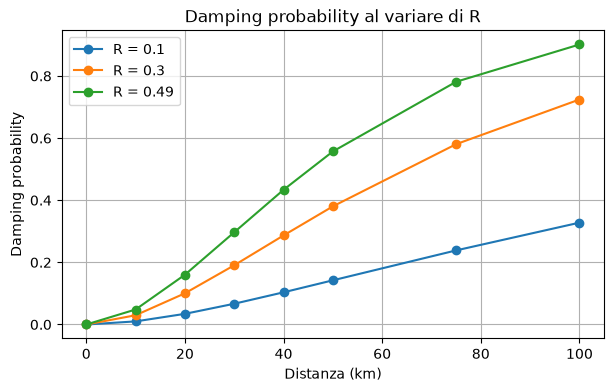

In [25]:
plt.figure(figsize=(7, 4))

for i in range(len(coupling_ratios)):
    current_r = coupling_ratios[i]
    temp_df = jc_multi_r_df[jc_multi_r_df["coupling_ratio"] == current_r]
    plt.plot(
        temp_df["distance_km"],
        temp_df["damping_probability"],
        marker="o",
        label=f"R = {current_r}",
    )

plt.xlabel("Distanza (km)")
plt.ylabel("Damping probability")
plt.title("Damping probability al variare di R")
plt.grid()
plt.legend()
plt.show()

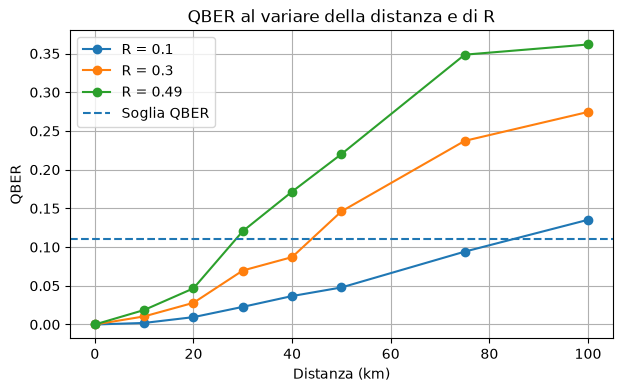

In [26]:
plt.figure(figsize=(7, 4))

for i in range(len(coupling_ratios)):
    current_r = coupling_ratios[i]
    temp_df = jc_multi_r_df[jc_multi_r_df["coupling_ratio"] == current_r]
    plt.plot(
        temp_df["distance_km"],
        temp_df["qber"],
        marker="o",
        label=f"R = {current_r}",
    )

plt.axhline(
    y=qber_threshold_jc,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Distanza (km)")
plt.ylabel("QBER")
plt.title("QBER al variare della distanza e di R")
plt.grid()
plt.legend()
plt.show()

## Tabella accepted/rejected

In [27]:
accepted_table = jc_multi_r_df.pivot(
    index="distance_km",
    columns="coupling_ratio",
    values="accepted",
)

accepted_table

coupling_ratio,0.10,0.30,0.49
distance_km,,,
0,True,True,True
10,True,True,True
20,True,True,True
30,True,True,False
40,True,True,False
50,True,False,False
75,True,False,False
100,False,False,False


La tabella mostra quali combinazioni distanza/R superano la soglia QBER e quindi portano al rifiuto della chiave. Un valore `True` indica che la chiave è accettata secondo la soglia scelta, mentre `False` indica che viene rifiutata.

## Commento interpretativo Jaynes-Cummings

Il modello Jaynes-Cummings semplificato collega la distanza a una probabilità effettiva di amplitude damping. Per `R = 0.1` la crescita può essere moderata; aumentando `R`, la `damping_probability` e il QBER possono crescere più rapidamente. Il QBER è la metrica principale per valutare la qualità della chiave, mentre il `sifted_key_rate` dipende soprattutto dal sifting delle basi e non rappresenta da solo la qualità del canale. Il modello resta semplificato: non include perdita esplicita di fotoni, dark counts, efficienza dei detector, riconciliazione dell'informazione o privacy amplification. Rispetto al modello fenomenologico generico, questa implementazione è più vicina all'articolo del docente perché passa da `C1(t)` e dal parametro `R`.

## Salvataggio dei risultati

In [28]:
from pathlib import Path

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Cartelle dei risultati pronte.")

Cartelle dei risultati pronte.


In [29]:
sweep_table_path = tables_dir / "bb84_bit_flip_noise_sweep.csv"
sweep_df.to_csv(sweep_table_path, index=False)

damping_table_path = tables_dir / "bb84_amplitude_damping_sweep.csv"
damping_sweep_df.to_csv(damping_table_path, index=False)

comparison_table_path = tables_dir / "bb84_noise_model_comparison.csv"
noise_comparison_df.to_csv(comparison_table_path, index=False)

jc_damping_table_path = tables_dir / "bb84_jc_damping_probability_vs_distance.csv"
jc_damping_df.to_csv(jc_damping_table_path, index=False)

jc_distance_table_path = tables_dir / "bb84_jc_qber_vs_distance_R_0_1.csv"
jc_distance_df.to_csv(jc_distance_table_path, index=False)

jc_multi_r_table_path = tables_dir / "bb84_jc_qber_vs_distance_multi_R.csv"
jc_multi_r_df.to_csv(jc_multi_r_table_path, index=False)

jc_acceptance_table_path = tables_dir / "bb84_jc_acceptance_table.csv"
accepted_table.to_csv(jc_acceptance_table_path)

print(f"Tabella bit-flip salvata in: {sweep_table_path}")
print(f"Tabella amplitude damping salvata in: {damping_table_path}")
print(f"Tabella confronto rumore salvata in: {comparison_table_path}")
print(f"Tabella damping JC salvata in: {jc_damping_table_path}")
print(f"Tabella QBER JC R=0.1 salvata in: {jc_distance_table_path}")
print(f"Tabella QBER JC multi-R salvata in: {jc_multi_r_table_path}")
print(f"Tabella acceptance JC salvata in: {jc_acceptance_table_path}")

Tabella bit-flip salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_bit_flip_noise_sweep.csv
Tabella amplitude damping salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_amplitude_damping_sweep.csv
Tabella confronto rumore salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_noise_model_comparison.csv
Tabella damping JC salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_jc_damping_probability_vs_distance.csv
Tabella QBER JC R=0.1 salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_jc_qber_vs_distance_R_0_1.csv
Tabella QBER JC multi-R salvata in: c

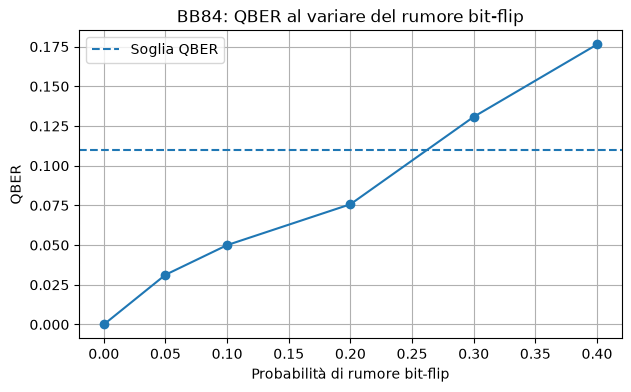

Grafico QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_bit_flip_qber_vs_noise.png


In [30]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("QBER")
plt.title("BB84: QBER al variare del rumore bit-flip")
plt.grid(True)
plt.legend()

qber_figure_path = figures_dir / "bb84_bit_flip_qber_vs_noise.png"
plt.savefig(qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER salvato in: {qber_figure_path}")

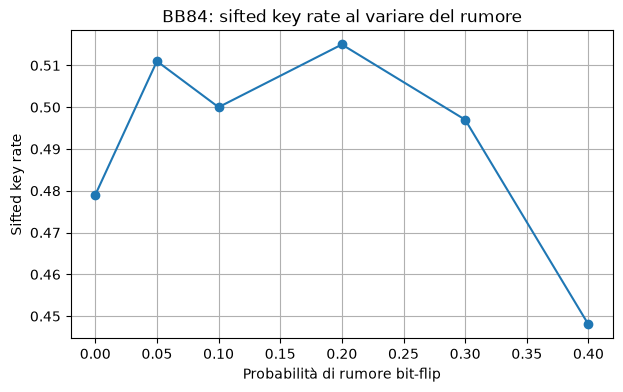

Grafico key rate salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_bit_flip_key_rate_vs_noise.png


In [31]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("Sifted key rate")
plt.title("BB84: sifted key rate al variare del rumore")
plt.grid(True)

key_rate_figure_path = figures_dir / "bb84_bit_flip_key_rate_vs_noise.png"
plt.savefig(key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico key rate salvato in: {key_rate_figure_path}")

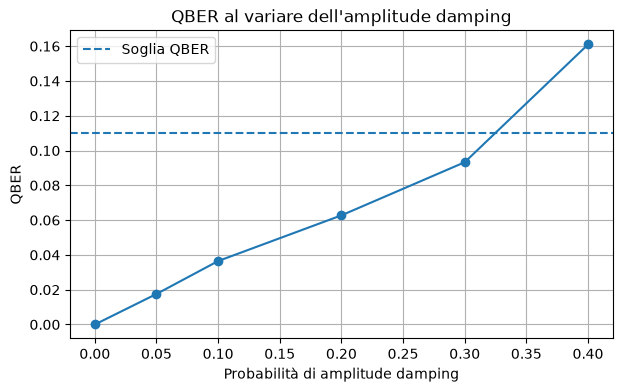

Grafico QBER amplitude damping salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_amplitude_damping_qber_vs_probability.png


In [32]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_damping_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("QBER")
plt.title("QBER al variare dell'amplitude damping")
plt.grid(True)
plt.legend()

damping_qber_figure_path = figures_dir / "bb84_amplitude_damping_qber_vs_probability.png"
plt.savefig(damping_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER amplitude damping salvato in: {damping_qber_figure_path}")

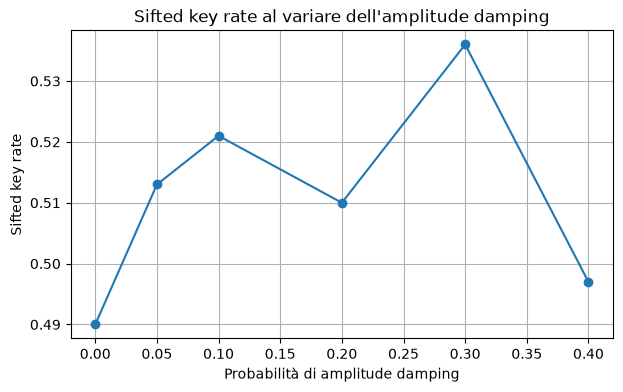

Grafico key rate amplitude damping salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_amplitude_damping_key_rate_vs_probability.png


In [33]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("Sifted key rate")
plt.title("Sifted key rate al variare dell'amplitude damping")
plt.grid(True)

damping_key_rate_figure_path = figures_dir / "bb84_amplitude_damping_key_rate_vs_probability.png"
plt.savefig(damping_key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico key rate amplitude damping salvato in: {damping_key_rate_figure_path}")

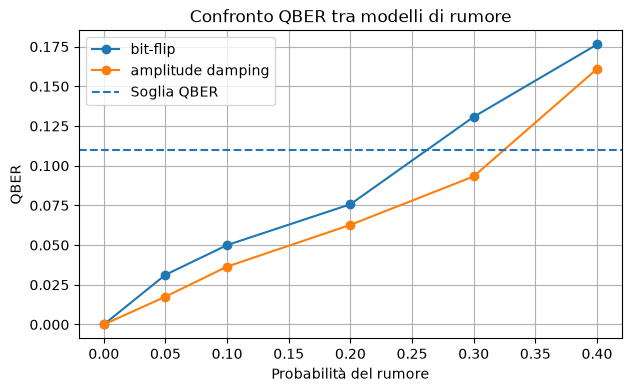

Grafico confronto QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_noise_models_qber_comparison.png


In [34]:
plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["qber"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["qber"],
    marker="o",
    label="amplitude damping",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("QBER")
plt.title("Confronto QBER tra modelli di rumore")
plt.grid(True)
plt.legend()

comparison_qber_figure_path = figures_dir / "bb84_noise_models_qber_comparison.png"
plt.savefig(comparison_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico confronto QBER salvato in: {comparison_qber_figure_path}")

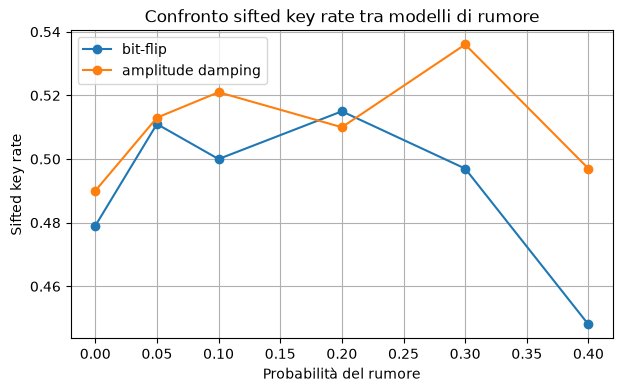

Grafico confronto key rate salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_noise_models_key_rate_comparison.png


In [35]:
plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["sifted_key_rate"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["sifted_key_rate"],
    marker="o",
    label="amplitude damping",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("Sifted key rate")
plt.title("Confronto sifted key rate tra modelli di rumore")
plt.grid(True)
plt.legend()

comparison_key_rate_figure_path = figures_dir / "bb84_noise_models_key_rate_comparison.png"
plt.savefig(comparison_key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico confronto key rate salvato in: {comparison_key_rate_figure_path}")

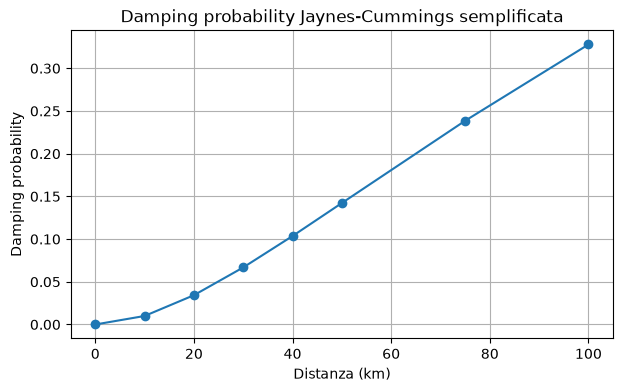

Grafico damping JC salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_damping_probability_vs_distance.png


In [36]:
plt.figure(figsize=(7, 4))
plt.plot(
    jc_damping_df["distance_km"],
    jc_damping_df["damping_probability"],
    marker="o",
)
plt.xlabel("Distanza (km)")
plt.ylabel("Damping probability")
plt.title("Damping probability Jaynes-Cummings semplificata")
plt.grid()

jc_damping_figure_path = figures_dir / "bb84_jc_damping_probability_vs_distance.png"
plt.savefig(jc_damping_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico damping JC salvato in: {jc_damping_figure_path}")

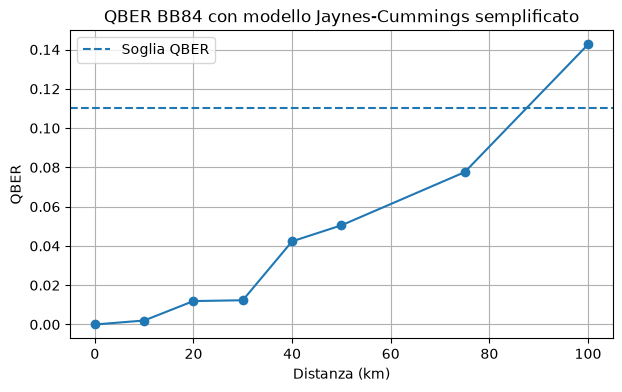

Grafico QBER JC R=0.1 salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_qber_vs_distance_R_0_1.png


In [37]:
plt.figure(figsize=(7, 4))
plt.plot(
    jc_distance_df["distance_km"],
    jc_distance_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_jc,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Distanza (km)")
plt.ylabel("QBER")
plt.title("QBER BB84 con modello Jaynes-Cummings semplificato")
plt.grid()
plt.legend()

jc_qber_figure_path = figures_dir / "bb84_jc_qber_vs_distance_R_0_1.png"
plt.savefig(jc_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER JC R=0.1 salvato in: {jc_qber_figure_path}")

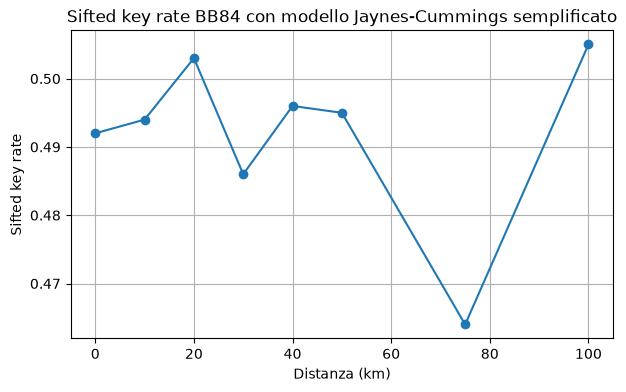

Grafico key rate JC R=0.1 salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_key_rate_vs_distance_R_0_1.png


In [38]:
plt.figure(figsize=(7, 4))
plt.plot(
    jc_distance_df["distance_km"],
    jc_distance_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Distanza (km)")
plt.ylabel("Sifted key rate")
plt.title("Sifted key rate BB84 con modello Jaynes-Cummings semplificato")
plt.grid()

jc_key_rate_figure_path = figures_dir / "bb84_jc_key_rate_vs_distance_R_0_1.png"
plt.savefig(jc_key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico key rate JC R=0.1 salvato in: {jc_key_rate_figure_path}")

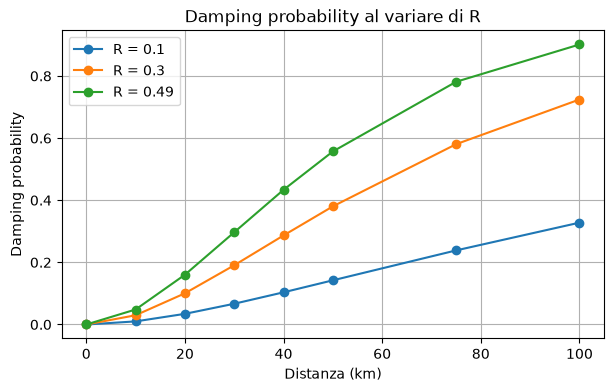

Grafico damping JC multi-R salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_damping_probability_multi_R.png


In [39]:
plt.figure(figsize=(7, 4))

for i in range(len(coupling_ratios)):
    current_r = coupling_ratios[i]
    temp_df = jc_multi_r_df[jc_multi_r_df["coupling_ratio"] == current_r]
    plt.plot(
        temp_df["distance_km"],
        temp_df["damping_probability"],
        marker="o",
        label=f"R = {current_r}",
    )

plt.xlabel("Distanza (km)")
plt.ylabel("Damping probability")
plt.title("Damping probability al variare di R")
plt.grid()
plt.legend()

jc_multi_r_damping_figure_path = figures_dir / "bb84_jc_damping_probability_multi_R.png"
plt.savefig(jc_multi_r_damping_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico damping JC multi-R salvato in: {jc_multi_r_damping_figure_path}")

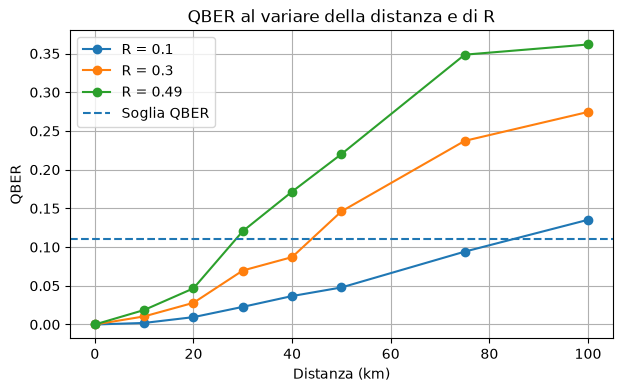

Grafico QBER JC multi-R salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_qber_multi_R.png


In [40]:
plt.figure(figsize=(7, 4))

for i in range(len(coupling_ratios)):
    current_r = coupling_ratios[i]
    temp_df = jc_multi_r_df[jc_multi_r_df["coupling_ratio"] == current_r]
    plt.plot(
        temp_df["distance_km"],
        temp_df["qber"],
        marker="o",
        label=f"R = {current_r}",
    )

plt.axhline(
    y=qber_threshold_jc,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Distanza (km)")
plt.ylabel("QBER")
plt.title("QBER al variare della distanza e di R")
plt.grid()
plt.legend()

jc_multi_r_qber_figure_path = figures_dir / "bb84_jc_qber_multi_R.png"
plt.savefig(jc_multi_r_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER JC multi-R salvato in: {jc_multi_r_qber_figure_path}")

## Rumore nel protocollo E91

Nel protocollo E91 il rumore pu? agire su uno o su entrambi i qubit della coppia entangled. Per questo notebook vengono considerati due modelli:

- `one_arm`: rumore applicato solo al qubit di Bob;
- `two_arm`: rumore applicato sia al qubit di Alice sia al qubit di Bob.

A differenza di BB84, per E91 non basta osservare il QBER. ? utile osservare anche la degradazione del parametro CHSH, perch? il rumore riduce la forza delle correlazioni quantistiche.


I valori scelti per gli sweep sono volutamente leggeri: permettono di osservare l'andamento del QBER e del parametro CHSH senza rendere il notebook troppo lento da eseguire.


In [ ]:
n_rounds_e91_noise = 500
shots_chsh_e91_noise = 1500
seed_e91_noise = 4321

e91_noise_probabilities = [0.0, 0.05, 0.10, 0.20, 0.30]
e91_damping_probabilities = [0.0, 0.05, 0.10, 0.20, 0.30]
e91_distances_km = [0, 10, 25, 50, 75, 100]
e91_channel_modes = ["one_arm", "two_arm"]


Usiamo un piccolo helper locale al notebook per riassumere i risultati E91 rumorosi. La funzione resta nel notebook perch? serve solo alla rappresentazione sperimentale di questa unit?.


In [ ]:
def summarize_e91_noise_protocol_results(
    results,
    qber,
    n_rounds,
    qber_threshold=QBER_THRESHOLD_BB84,
):
    sifted_key_length = 0

    for row in results:
        if row["keep"] is True:
            sifted_key_length += 1

    sifted_key_rate = sifted_key_length / n_rounds

    return {
        "n_rounds": n_rounds,
        "sifted_key_length": sifted_key_length,
        "sifted_key_rate": sifted_key_rate,
        "qber": qber,
        "qber_threshold": qber_threshold,
        "accepted_by_qber": qber <= qber_threshold,
    }


## E91 con bit-flip noise

Il bit-flip applica una porta `X` probabilistica sui qubit che attraversano il canale. Nel caso `one_arm` viene alterato solo il qubit di Bob; nel caso `two_arm` vengono alterati entrambi i qubit della coppia entangled.


In [ ]:
rows = []

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]

    for probability_index in range(len(e91_noise_probabilities)):
        noise_probability = e91_noise_probabilities[probability_index]
        current_seed = seed_e91_noise + mode_index * 100 + probability_index

        results = run_e91_protocol_with_bit_flip_noise(
            n_rounds=n_rounds_e91_noise,
            noise_probability=noise_probability,
            channel_mode=channel_mode,
            seed=current_seed,
        )
        alice_key, bob_key = sift_keys_e91(results)
        qber = compute_qber_e91(alice_key, bob_key)

        chsh_result = run_chsh_experiment_with_bit_flip_noise(
            noise_probability=noise_probability,
            channel_mode=channel_mode,
            shots=shots_chsh_e91_noise,
            seed=current_seed,
        )
        summary = summarize_e91_noise_protocol_results(
            results,
            qber,
            n_rounds_e91_noise,
        )

        row = {
            "protocol": "E91",
            "noise_type": "bit_flip",
            "channel_mode": channel_mode,
            "noise_probability": noise_probability,
            "n_rounds": summary["n_rounds"],
            "sifted_key_length": summary["sifted_key_length"],
            "sifted_key_rate": summary["sifted_key_rate"],
            "qber": summary["qber"],
            "qber_threshold": summary["qber_threshold"],
            "accepted_by_qber": summary["accepted_by_qber"],
            "abs_S": chsh_result["abs_S"],
            "violates_chsh": chsh_result["violates_chsh"],
            "chsh_gap": chsh_result["chsh_gap"],
            "chsh_strength": chsh_result["chsh_strength"],
            "classical_limit": chsh_result["classical_limit"],
            "quantum_limit": chsh_result["quantum_limit"],
        }
        rows.append(row)


e91_bit_flip_noise_df = pd.DataFrame(rows)

bit_flip_e91_table_path = tables_dir / "e91_bit_flip_noise_sweep.csv"
e91_bit_flip_noise_df.to_csv(bit_flip_e91_table_path, index=False)

print(f"Tabella E91 bit-flip salvata in: {bit_flip_e91_table_path}")
e91_bit_flip_noise_df


In [ ]:
plt.figure(figsize=(7, 4))

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]
    mode_df = e91_bit_flip_noise_df[e91_bit_flip_noise_df["channel_mode"] == channel_mode]
    plt.plot(
        mode_df["noise_probability"],
        mode_df["qber"],
        marker="o",
        label=channel_mode,
    )

plt.axhline(
    y=QBER_THRESHOLD_BB84,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilit? di bit-flip")
plt.ylabel("QBER")
plt.title("E91: QBER al variare del bit-flip noise")
plt.grid(True)
plt.legend()

figure_path = figures_dir / "e91_bit_flip_qber_vs_noise.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico E91 bit-flip QBER salvato in: {figure_path}")


In [ ]:
plt.figure(figsize=(7, 4))

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]
    mode_df = e91_bit_flip_noise_df[e91_bit_flip_noise_df["channel_mode"] == channel_mode]
    plt.plot(
        mode_df["noise_probability"],
        mode_df["abs_S"],
        marker="o",
        label=channel_mode,
    )

plt.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", label="Limite classico")
plt.axhline(CHSH_TSIRELSON_BOUND, linestyle=":", label="Limite di Tsirelson")
plt.xlabel("Probabilit? di bit-flip")
plt.ylabel("|S|")
plt.title("E91: CHSH al variare del bit-flip noise")
plt.grid(True)
plt.legend()

figure_path = figures_dir / "e91_bit_flip_chsh_vs_noise.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico E91 bit-flip CHSH salvato in: {figure_path}")


## E91 con amplitude damping

L'amplitude damping simula una dissipazione energetica del qubit e tende a favorire il decadimento verso `|0>`. In E91 questo pu? degradare sia il QBER sia la violazione CHSH.


In [ ]:
rows = []

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]

    for probability_index in range(len(e91_damping_probabilities)):
        damping_probability = e91_damping_probabilities[probability_index]
        current_seed = seed_e91_noise + 1000 + mode_index * 100 + probability_index

        results = run_e91_protocol_with_amplitude_damping(
            n_rounds=n_rounds_e91_noise,
            damping_probability=damping_probability,
            channel_mode=channel_mode,
            seed=current_seed,
        )
        alice_key, bob_key = sift_keys_e91(results)
        qber = compute_qber_e91(alice_key, bob_key)

        chsh_result = run_chsh_experiment_with_amplitude_damping(
            damping_probability=damping_probability,
            channel_mode=channel_mode,
            shots=shots_chsh_e91_noise,
            seed=current_seed,
        )
        summary = summarize_e91_noise_protocol_results(
            results,
            qber,
            n_rounds_e91_noise,
        )

        row = {
            "protocol": "E91",
            "noise_type": "amplitude_damping",
            "channel_mode": channel_mode,
            "damping_probability": damping_probability,
            "n_rounds": summary["n_rounds"],
            "sifted_key_length": summary["sifted_key_length"],
            "sifted_key_rate": summary["sifted_key_rate"],
            "qber": summary["qber"],
            "qber_threshold": summary["qber_threshold"],
            "accepted_by_qber": summary["accepted_by_qber"],
            "abs_S": chsh_result["abs_S"],
            "violates_chsh": chsh_result["violates_chsh"],
            "chsh_gap": chsh_result["chsh_gap"],
            "chsh_strength": chsh_result["chsh_strength"],
            "classical_limit": chsh_result["classical_limit"],
            "quantum_limit": chsh_result["quantum_limit"],
        }
        rows.append(row)


e91_amplitude_damping_df = pd.DataFrame(rows)

amplitude_e91_table_path = tables_dir / "e91_amplitude_damping_sweep.csv"
e91_amplitude_damping_df.to_csv(amplitude_e91_table_path, index=False)

print(f"Tabella E91 amplitude damping salvata in: {amplitude_e91_table_path}")
e91_amplitude_damping_df


In [ ]:
plt.figure(figsize=(7, 4))

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]
    mode_df = e91_amplitude_damping_df[e91_amplitude_damping_df["channel_mode"] == channel_mode]
    plt.plot(
        mode_df["damping_probability"],
        mode_df["qber"],
        marker="o",
        label=channel_mode,
    )

plt.axhline(
    y=QBER_THRESHOLD_BB84,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilit? di amplitude damping")
plt.ylabel("QBER")
plt.title("E91: QBER al variare dell'amplitude damping")
plt.grid(True)
plt.legend()

figure_path = figures_dir / "e91_amplitude_damping_qber_vs_probability.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico E91 amplitude damping QBER salvato in: {figure_path}")


In [ ]:
plt.figure(figsize=(7, 4))

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]
    mode_df = e91_amplitude_damping_df[e91_amplitude_damping_df["channel_mode"] == channel_mode]
    plt.plot(
        mode_df["damping_probability"],
        mode_df["abs_S"],
        marker="o",
        label=channel_mode,
    )

plt.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", label="Limite classico")
plt.axhline(CHSH_TSIRELSON_BOUND, linestyle=":", label="Limite di Tsirelson")
plt.xlabel("Probabilit? di amplitude damping")
plt.ylabel("|S|")
plt.title("E91: CHSH al variare dell'amplitude damping")
plt.grid(True)
plt.legend()

figure_path = figures_dir / "e91_amplitude_damping_chsh_vs_probability.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico E91 amplitude damping CHSH salvato in: {figure_path}")


## E91 con modello Jaynes-Cummings e distanza

Il modello Jaynes-Cummings gi? usato per BB84 viene esteso in modo didattico a E91. Nel caso `one_arm` l'intera distanza ? assegnata al braccio di Bob. Nel caso `two_arm` la sorgente ? interpretata come posta idealmente al centro, quindi ciascun qubit attraversa met? della distanza totale Alice-Bob.


In [ ]:
rows = []

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]

    for distance_index in range(len(e91_distances_km)):
        distance_km = e91_distances_km[distance_index]
        current_seed = seed_e91_noise + 2000 + mode_index * 100 + distance_index

        params = compute_e91_jc_channel_parameters(
            distance_km,
            channel_mode=channel_mode,
        )

        results = run_e91_protocol_with_jc_amplitude_damping(
            n_rounds=n_rounds_e91_noise,
            distance_km=distance_km,
            channel_mode=channel_mode,
            seed=current_seed,
        )
        alice_key, bob_key = sift_keys_e91(results)
        qber = compute_qber_e91(alice_key, bob_key)

        chsh_result = run_chsh_experiment_with_jc_amplitude_damping(
            distance_km=distance_km,
            channel_mode=channel_mode,
            shots=shots_chsh_e91_noise,
            seed=current_seed,
        )
        summary = summarize_e91_noise_protocol_results(
            results,
            qber,
            n_rounds_e91_noise,
        )

        row = {
            "protocol": "E91",
            "noise_type": "jc_amplitude_damping",
            "channel_mode": channel_mode,
            "distance_km": distance_km,
            "arm_distance_alice_km": params["arm_distance_alice_km"],
            "arm_distance_bob_km": params["arm_distance_bob_km"],
            "damping_probability_alice": params["damping_probability_alice"],
            "damping_probability_bob": params["damping_probability_bob"],
            "n_rounds": summary["n_rounds"],
            "sifted_key_length": summary["sifted_key_length"],
            "sifted_key_rate": summary["sifted_key_rate"],
            "qber": summary["qber"],
            "qber_threshold": summary["qber_threshold"],
            "accepted_by_qber": summary["accepted_by_qber"],
            "abs_S": chsh_result["abs_S"],
            "violates_chsh": chsh_result["violates_chsh"],
            "chsh_gap": chsh_result["chsh_gap"],
            "chsh_strength": chsh_result["chsh_strength"],
            "classical_limit": chsh_result["classical_limit"],
            "quantum_limit": chsh_result["quantum_limit"],
        }
        rows.append(row)


e91_jc_distance_df = pd.DataFrame(rows)

jc_e91_table_path = tables_dir / "e91_jc_distance_sweep.csv"
e91_jc_distance_df.to_csv(jc_e91_table_path, index=False)

print(f"Tabella E91 Jaynes-Cummings salvata in: {jc_e91_table_path}")
e91_jc_distance_df


In [ ]:
plt.figure(figsize=(7, 4))

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]
    mode_df = e91_jc_distance_df[e91_jc_distance_df["channel_mode"] == channel_mode]
    plt.plot(
        mode_df["distance_km"],
        mode_df["qber"],
        marker="o",
        label=channel_mode,
    )

plt.axhline(
    y=QBER_THRESHOLD_BB84,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Distanza (km)")
plt.ylabel("QBER")
plt.title("E91: QBER con modello Jaynes-Cummings")
plt.grid(True)
plt.legend()

figure_path = figures_dir / "e91_jc_qber_vs_distance.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico E91 JC QBER salvato in: {figure_path}")


In [ ]:
plt.figure(figsize=(7, 4))

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]
    mode_df = e91_jc_distance_df[e91_jc_distance_df["channel_mode"] == channel_mode]
    plt.plot(
        mode_df["distance_km"],
        mode_df["abs_S"],
        marker="o",
        label=channel_mode,
    )

plt.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", label="Limite classico")
plt.axhline(CHSH_TSIRELSON_BOUND, linestyle=":", label="Limite di Tsirelson")
plt.xlabel("Distanza (km)")
plt.ylabel("|S|")
plt.title("E91: CHSH con modello Jaynes-Cummings")
plt.grid(True)
plt.legend()

figure_path = figures_dir / "e91_jc_chsh_vs_distance.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico E91 JC CHSH salvato in: {figure_path}")


In [ ]:
plt.figure(figsize=(7, 4))

for mode_index in range(len(e91_channel_modes)):
    channel_mode = e91_channel_modes[mode_index]
    mode_df = e91_jc_distance_df[e91_jc_distance_df["channel_mode"] == channel_mode]
    plt.plot(
        mode_df["distance_km"],
        mode_df["damping_probability_bob"],
        marker="o",
        label=channel_mode,
    )

plt.xlabel("Distanza (km)")
plt.ylabel("Damping probability Bob")
plt.title("E91: damping probability di Bob al variare della distanza")
plt.grid(True)
plt.legend()

figure_path = figures_dir / "e91_jc_damping_probability_vs_distance.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico E91 JC damping salvato in: {figure_path}")


## Tabella sintetica E91 rumore

Raccogliamo in un'unica tabella i risultati E91 ottenuti con bit-flip, amplitude damping e modello Jaynes-Cummings in funzione della distanza.


In [ ]:
e91_noise_summary_df = pd.concat(
    [
        e91_bit_flip_noise_df,
        e91_amplitude_damping_df,
        e91_jc_distance_df,
    ],
    ignore_index=True,
)

summary_e91_table_path = tables_dir / "e91_noise_summary.csv"
e91_noise_summary_df.to_csv(summary_e91_table_path, index=False)

print(f"Tabella sintetica E91 rumore salvata in: {summary_e91_table_path}")
e91_noise_summary_df


## Commento finale sul rumore E91

Il rumore E91 mostra due effetti paralleli:

- aumento del QBER;
- degradazione della violazione CHSH.

Il confronto `one_arm` / `two_arm` consente di distinguere uno scenario in cui solo un qubit attraversa il canale rumoroso da uno scenario in cui entrambi i qubit della coppia entangled sono soggetti al canale. Il modello `two_arm` ? particolarmente utile per discutere la distribuzione entanglement-based su una distanza Alice-Bob, mentre `one_arm` ? utile per un confronto pi? diretto con BB84.

Il modello Jaynes-Cummings applicato a E91 ? una estensione didattica ed euristica del modello usato per BB84: aiuta a collegare distanza e damping, ma non rappresenta una replica completa di un sistema fisico reale.
